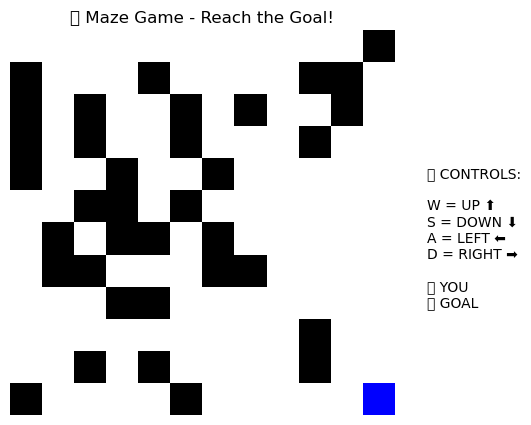

🎉 YOU REACHED THE GOAL!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time
from IPython.display import clear_output

# Maze size
rows, cols = 12, 12

# Generate maze
maze = np.zeros((rows, cols))
for i in range(rows):
    for j in range(cols):
        if random.random() < 0.25:
            maze[i][j] = 1

start = (0, 0)
goal = (rows-1, cols-1)

maze[start] = 0
maze[goal] = 0

player_pos = list(start)

while True:
    
    # Create colored grid
    grid = np.ones((rows, cols, 3))  # white background

    # Walls (black)
    for i in range(rows):
        for j in range(cols):
            if maze[i][j] == 1:
                grid[i][j] = [0, 0, 0]

    # Goal (green)
    grid[goal] = [0, 1, 0]

    # Player (blue)
    grid[player_pos[0]][player_pos[1]] = [0, 0, 1]

    clear_output(wait=True)

    # Plot with controls on side
    fig, ax = plt.subplots(figsize=(8,5))
    ax.imshow(grid)
    ax.axis('off')

    controls = (
        "🎮 CONTROLS:\n\n"
        "W = UP ⬆️\n"
        "S = DOWN ⬇️\n"
        "A = LEFT ⬅️\n"
        "D = RIGHT ➡️\n\n"
        "🔵 YOU\n"
        "🟢 GOAL"
    )

    plt.text(cols + 0.5, rows/2, controls,
             fontsize=10, va='center')

    plt.title("🧩 Maze Game - Reach the Goal!")
    plt.show()

    # Check win
    if tuple(player_pos) == goal:
        print("🎉 YOU REACHED THE GOAL!")
        break

    # User input
    move = input("Move (w/a/s/d): ").lower()

    dx, dy = 0, 0
    if move == 'w': dx = -1
    elif move == 's': dx = 1
    elif move == 'a': dy = -1
    elif move == 'd': dy = 1

    nx = player_pos[0] + dx
    ny = player_pos[1] + dy

    # Move if valid
    if 0 <= nx < rows and 0 <= ny < cols and maze[nx][ny] == 0:
        player_pos = [nx, ny]

    time.sleep(0.1)